## Modeling

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("../data/processed/train.csv")
val = pd.read_csv("../data/processed/val.csv")

FEATURES = [f"V{i}" for i in range(1, 29)] + ["log_amount", "hour"]
TARGET = "Class"

X_train, y_train = train[FEATURES], train[TARGET]
X_val, y_val = val[FEATURES], val[TARGET]

print(X_train.shape, X_val.shape)
print("frauds:", y_train.sum(), y_val.sum())

(198608, 30) (42559, 30)
frauds: 331 71


## Metrics

A model outputs a **probability** of fraud for each transaction. Flagging every transaction with probability >= a **threshold** (0.5 by default) gives:
- **Precision:** of the transactions I flagged, how many were really fraud?
- **Recall:** of the real frauds, how many did I catch?
- **PR-AUC (average precision):** one number summarizing precision and recall across ALL thresholds. It doesn't depend on the threshold, so it's my main metric. A model with no skill scores about 0.0017 (the fraud rate).

Example: validation has 71 frauds. If I flag 80 transactions and 60 are real fraud,
precision = 60/80 = 75% and recall = 60/71 = 85%.

In [2]:
from sklearn.metrics import (average_precision_score, precision_score,
                            recall_score, f1_score)

def evaluate(y_true, proba, threshold=0.5):
    y = np.asarray(y_true)
    pred = (np.asarray(proba) >= threshold).astype(int)
    return {
        "pr_auc": average_precision_score(y, proba),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred),
        "frauds_caught": int(((pred == 1) & (y == 1)).sum()),
        "false_alarms": int(((pred == 1) & (y == 0)).sum()),
    }

evaluate(y_val, np.zeros(len(y_val)))

{'pr_auc': 0.0016682722808336662,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'frauds_caught': 0,
 'false_alarms': 0}

## Logistic Regression

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000)),
])
lr.fit(X_train, y_train)

proba_lr = lr.predict_proba(X_val)[:, 1]
evaluate(y_val, proba_lr)

{'pr_auc': 0.6968193654166647,
 'precision': 0.8333333333333334,
 'recall': 0.49295774647887325,
 'f1': 0.6194690265486725,
 'frauds_caught': 35,
 'false_alarms': 7}

## - Adding class weights

In [4]:
lr_bal = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
lr_bal.fit(X_train, y_train)

proba_lr_bal = lr_bal.predict_proba(X_val)[:, 1]
evaluate(y_val, proba_lr_bal)

{'pr_auc': 0.7049014030957027,
 'precision': 0.04868624420401855,
 'recall': 0.8873239436619719,
 'f1': 0.09230769230769231,
 'frauds_caught': 63,
 'false_alarms': 1231}

## - Plot the precision-recall curves

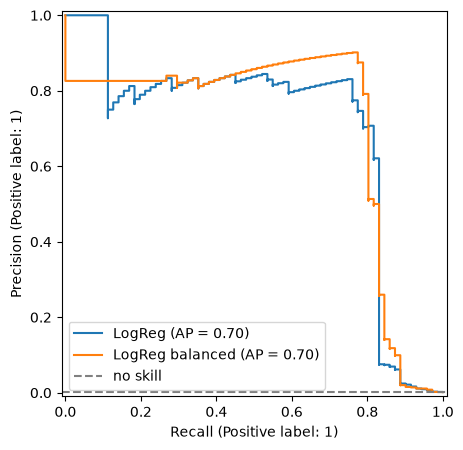

In [5]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_val, proba_lr, name="LogReg", ax=ax)
PrecisionRecallDisplay.from_predictions(y_val, proba_lr_bal, name="LogReg balanced", ax=ax)
ax.axhline(y_val.mean(), ls="--", c="gray", label="no skill")
ax.legend()
plt.show()

## - See what the model uses

In [6]:
coefs = pd.Series(lr.named_steps["clf"].coef_[0], index=FEATURES)
coefs.sort_values(key=abs, ascending=False).head(8)

V4     0.698439
V14   -0.612771
V10   -0.511216
V9    -0.269891
V8    -0.267509
V22    0.264211
V16   -0.203449
V15   -0.198177
dtype: float64

## Notes

- LogReg (plain): PR-AUC 0.69, precision 0.83, recall 0.49, false alarms 7
- LogReg (balanced): PR-AUC 0.7, precision 0.04, recall 0.88, false alarms 1231
- Class weights changed precision/recall at threshold 0.5 a lot, but PR-AUC only +0.01 because they mostly shift the probabilities, so the threshold has to be chosen deliberately.

## Cross-validation and imbalance strategies
## - Set up the experiment tools

In [7]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

SCORING = {
    "pr_auc": "average_precision",
    "recall": make_scorer(recall_score),
    "precision": make_scorer(precision_score, zero_division=0),
}

RESULTS_PATH = Path("../reports/crossValidation_results.csv")
results = []

def run_cv(model_name, imbalance, estimator, params=None):
    start = time.time()
    scores = cross_validate(estimator, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=1)
    row = {
        "model": model_name,
        "imbalance": imbalance,
        "pr_auc": scores["test_pr_auc"].mean(),
        "pr_auc_std": scores["test_pr_auc"].std(),
        "recall": scores["test_recall"].mean(),
        "precision": scores["test_precision"].mean(),
        "seconds": round(time.time() - start),
        "params": str(params or {}),
    }
    results.append(row)
    pd.DataFrame(results).to_csv(RESULTS_PATH, index=False)   # saved after every run
    print({k: (round(v, 3) if isinstance(v, float) else v) for k, v in row.items()})
    return row

## - Defining the four strategies

In [8]:
def lr_pipeline(sampler=None, class_weight=None):
    steps = [("scaler", StandardScaler())]
    if sampler is not None:
        steps.append(("sampler", sampler))
    steps.append(("clf", LogisticRegression(max_iter=1000, class_weight=class_weight)))
    return ImbPipeline(steps)

In [9]:
run_cv("LogReg", "none", lr_pipeline())

{'model': 'LogReg', 'imbalance': 'none', 'pr_auc': np.float64(0.756), 'pr_auc_std': np.float64(0.039), 'recall': np.float64(0.628), 'precision': np.float64(0.868), 'seconds': 1, 'params': '{}'}


{'model': 'LogReg',
 'imbalance': 'none',
 'pr_auc': np.float64(0.7557830338601642),
 'pr_auc_std': np.float64(0.038663650626662015),
 'recall': np.float64(0.6284938941655359),
 'precision': np.float64(0.8676002381277865),
 'seconds': 1,
 'params': '{}'}

In [10]:
run_cv("LogReg", "class_weight", lr_pipeline(class_weight="balanced"))

{'model': 'LogReg', 'imbalance': 'class_weight', 'pr_auc': np.float64(0.754), 'pr_auc_std': np.float64(0.04), 'recall': np.float64(0.906), 'precision': np.float64(0.053), 'seconds': 2, 'params': '{}'}


{'model': 'LogReg',
 'imbalance': 'class_weight',
 'pr_auc': np.float64(0.7544952135793643),
 'pr_auc_std': np.float64(0.03974776497549821),
 'recall': np.float64(0.9064676616915422),
 'precision': np.float64(0.05288147994010191),
 'seconds': 2,
 'params': '{}'}

In [11]:
run_cv("LogReg", "undersample",
       lr_pipeline(RandomUnderSampler(sampling_strategy=0.1, random_state=42)))

{'model': 'LogReg', 'imbalance': 'undersample', 'pr_auc': np.float64(0.714), 'pr_auc_std': np.float64(0.08), 'recall': np.float64(0.864), 'precision': np.float64(0.339), 'seconds': 1, 'params': '{}'}


{'model': 'LogReg',
 'imbalance': 'undersample',
 'pr_auc': np.float64(0.7143174088935733),
 'pr_auc_std': np.float64(0.07952296036346496),
 'recall': np.float64(0.864179104477612),
 'precision': np.float64(0.33909105279481355),
 'seconds': 1,
 'params': '{}'}

In [12]:
run_cv("LogReg", "SMOTE",
       lr_pipeline(SMOTE(sampling_strategy=0.1, random_state=42)))

{'model': 'LogReg', 'imbalance': 'SMOTE', 'pr_auc': np.float64(0.757), 'pr_auc_std': np.float64(0.046), 'recall': np.float64(0.858), 'precision': np.float64(0.395), 'seconds': 2, 'params': '{}'}


{'model': 'LogReg',
 'imbalance': 'SMOTE',
 'pr_auc': np.float64(0.7574587091716548),
 'pr_auc_std': np.float64(0.04624151902567799),
 'recall': np.float64(0.8582089552238805),
 'precision': np.float64(0.39479770531505615),
 'seconds': 2,
 'params': '{}'}

In [13]:
pd.DataFrame(results).round(3)

,model,imbalance,pr_auc,pr_auc_std,recall,precision,seconds,params
0,LogReg,none,0.756,0.039,0.628,0.868,1,{}
1,LogReg,class_weight,0.754,0.040,0.906,0.053,2,{}
2,LogReg,undersample,0.714,0.080,0.864,0.339,1,{}
3,LogReg,SMOTE,0.757,0.046,0.858,0.395,2,{}


## Log Regression Notes

- Best LogReg strategy by PR-AUC: SMOTE (0.757 ± 0.046), but not meaningfully better
  than `none` (0.756 ± 0.039) — the difference is much smaller than the std, so it's noise.
- Precision/recall at 0.5 vary a lot between strategies (e.g. class_weight: 0.053
  precision, 0.906 recall) because rebalancing shifts probabilities rather than
  improving ranking quality (PR-AUC stays flat).
- Undersampling has the lowest PR-AUC (0.714), likely because it discards most
  normal transactions and loses information.

## Random Forest

## - Define the pipeline

In [14]:
from sklearn.ensemble import RandomForestClassifier

def rf_pipeline(sampler=None, class_weight=None):
    steps = [("scaler", StandardScaler())]
    if sampler is not None:
        steps.append(("sampler", sampler))
    steps.append(("clf", RandomForestClassifier(
        n_estimators=100, max_depth=12, n_jobs=-1,
        random_state=42, class_weight=class_weight)))
    return ImbPipeline(steps)

RF_PARAMS = {"n_estimators": 100, "max_depth": 12}

## - Running the four strategies

In [15]:
run_cv("RandomForest", "none", rf_pipeline(), RF_PARAMS)

{'model': 'RandomForest', 'imbalance': 'none', 'pr_auc': np.float64(0.843), 'pr_auc_std': np.float64(0.024), 'recall': np.float64(0.764), 'precision': np.float64(0.935), 'seconds': 39, 'params': "{'n_estimators': 100, 'max_depth': 12}"}


{'model': 'RandomForest',
 'imbalance': 'none',
 'pr_auc': np.float64(0.8425620144245084),
 'pr_auc_std': np.float64(0.024159052220963463),
 'recall': np.float64(0.7644052464947986),
 'precision': np.float64(0.9353990924521878),
 'seconds': 39,
 'params': "{'n_estimators': 100, 'max_depth': 12}"}

In [16]:
run_cv("RandomForest", "class_weight",
    rf_pipeline(class_weight="balanced_subsample"), RF_PARAMS)

{'model': 'RandomForest', 'imbalance': 'class_weight', 'pr_auc': np.float64(0.826), 'pr_auc_std': np.float64(0.032), 'recall': np.float64(0.789), 'precision': np.float64(0.887), 'seconds': 28, 'params': "{'n_estimators': 100, 'max_depth': 12}"}


{'model': 'RandomForest',
 'imbalance': 'class_weight',
 'pr_auc': np.float64(0.8262929983858968),
 'pr_auc_std': np.float64(0.03237280341561583),
 'recall': np.float64(0.7886024423337856),
 'precision': np.float64(0.8865729959373307),
 'seconds': 28,
 'params': "{'n_estimators': 100, 'max_depth': 12}"}

In [17]:
run_cv("RandomForest", "undersample",
    rf_pipeline(RandomUnderSampler(sampling_strategy=0.1, random_state=42)), RF_PARAMS)

{'model': 'RandomForest', 'imbalance': 'undersample', 'pr_auc': np.float64(0.766), 'pr_auc_std': np.float64(0.03), 'recall': np.float64(0.852), 'precision': np.float64(0.564), 'seconds': 2, 'params': "{'n_estimators': 100, 'max_depth': 12}"}


{'model': 'RandomForest',
 'imbalance': 'undersample',
 'pr_auc': np.float64(0.7661580429733983),
 'pr_auc_std': np.float64(0.030118734549329233),
 'recall': np.float64(0.8521031207598371),
 'precision': np.float64(0.5637266238418308),
 'seconds': 2,
 'params': "{'n_estimators': 100, 'max_depth': 12}"}

In [18]:
run_cv("RandomForest", "SMOTE",
    rf_pipeline(SMOTE(sampling_strategy=0.1, random_state=42)), RF_PARAMS)

{'model': 'RandomForest', 'imbalance': 'SMOTE', 'pr_auc': np.float64(0.846), 'pr_auc_std': np.float64(0.027), 'recall': np.float64(0.831), 'precision': np.float64(0.863), 'seconds': 45, 'params': "{'n_estimators': 100, 'max_depth': 12}"}


{'model': 'RandomForest',
 'imbalance': 'SMOTE',
 'pr_auc': np.float64(0.8463298981663986),
 'pr_auc_std': np.float64(0.026706460629821616),
 'recall': np.float64(0.8308909995477161),
 'precision': np.float64(0.8630497763621576),
 'seconds': 45,
 'params': "{'n_estimators': 100, 'max_depth': 12}"}

In [19]:
pd.DataFrame(results).round(3)

,model,imbalance,pr_auc,pr_auc_std,recall,precision,seconds,params
0,LogReg,none,0.756,0.039,0.628,0.868,1,{}
1,LogReg,class_weight,0.754,0.040,0.906,0.053,2,{}
2,LogReg,undersample,0.714,0.080,0.864,0.339,1,{}
3,LogReg,SMOTE,0.757,0.046,0.858,0.395,2,{}
4,RandomForest,none,0.843,0.024,0.764,0.935,39,"{'n_estimators': 100, 'max_depth': 12}"
5,RandomForest,class_weight,0.826,0.032,0.789,0.887,28,"{'n_estimators': 100, 'max_depth': 12}"
6,RandomForest,undersample,0.766,0.030,0.852,0.564,2,"{'n_estimators': 100, 'max_depth': 12}"
7,RandomForest,SMOTE,0.846,0.027,0.831,0.863,45,"{'n_estimators': 100, 'max_depth': 12}"


## Random Forest Notes

- Best RandomForest strategy by PR-AUC: SMOTE (0.846 ± 0.027), but essentially tied with `none` (0.843 ± 0.024) — the difference is well within the std, so not meaningful.
- RandomForest clearly beats LogReg: best PR-AUC ~0.84-0.85 vs ~0.75-0.76 for LogReg, a difference much larger than the std, so this is a real improvement.
- class_weight (0.826) is slightly below `none`, and undersample is again the weakest (0.766) and fastest (2s vs 32-51s for the others).
- Plain RandomForest (no rebalancing) already gives strong precision (0.935) and decent recall (0.764) at the default threshold.

## XGBoost

## - Computing the class weight

In [20]:
from xgboost import XGBClassifier

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f"negatives: {neg}, positives: {pos}, ratio: {spw:.0f}")   # ratio about 600

negatives: 198277, positives: 331, ratio: 599


## - Defining the model and running three experiments

In [21]:
def make_xgb(scale_pos_weight=1):
    return XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        tree_method="hist", n_jobs=-1, random_state=42,
    )

XGB_PARAMS = {"n_estimators": 300, "max_depth": 4, "learning_rate": 0.1}

In [22]:
run_cv("XGBoost", "none", make_xgb(1), XGB_PARAMS)

{'model': 'XGBoost', 'imbalance': 'none', 'pr_auc': np.float64(0.855), 'pr_auc_std': np.float64(0.027), 'recall': np.float64(0.801), 'precision': np.float64(0.944), 'seconds': 10, 'params': "{'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1}"}


{'model': 'XGBoost',
 'imbalance': 'none',
 'pr_auc': np.float64(0.8548999557362388),
 'pr_auc_std': np.float64(0.026868792550771584),
 'recall': np.float64(0.8006784260515604),
 'precision': np.float64(0.9441278658896856),
 'seconds': 10,
 'params': "{'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1}"}

In [23]:
run_cv("XGBoost", "scale_pos_weight full", make_xgb(spw), XGB_PARAMS)

{'model': 'XGBoost', 'imbalance': 'scale_pos_weight full', 'pr_auc': np.float64(0.855), 'pr_auc_std': np.float64(0.029), 'recall': np.float64(0.828), 'precision': np.float64(0.896), 'seconds': 10, 'params': "{'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1}"}


{'model': 'XGBoost',
 'imbalance': 'scale_pos_weight full',
 'pr_auc': np.float64(0.8545007254047909),
 'pr_auc_std': np.float64(0.02923607236922687),
 'recall': np.float64(0.8279059249208502),
 'precision': np.float64(0.8955577204290535),
 'seconds': 10,
 'params': "{'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1}"}

In [24]:
run_cv("XGBoost", "scale_pos_weight sqrt", make_xgb(spw ** 0.5), XGB_PARAMS)

{'model': 'XGBoost', 'imbalance': 'scale_pos_weight sqrt', 'pr_auc': np.float64(0.855), 'pr_auc_std': np.float64(0.028), 'recall': np.float64(0.825), 'precision': np.float64(0.918), 'seconds': 10, 'params': "{'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1}"}


{'model': 'XGBoost',
 'imbalance': 'scale_pos_weight sqrt',
 'pr_auc': np.float64(0.855252730586539),
 'pr_auc_std': np.float64(0.028437933878984644),
 'recall': np.float64(0.8249208502939845),
 'precision': np.float64(0.9176552035827272),
 'seconds': 10,
 'params': "{'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1}"}

## - What did the model learn ?

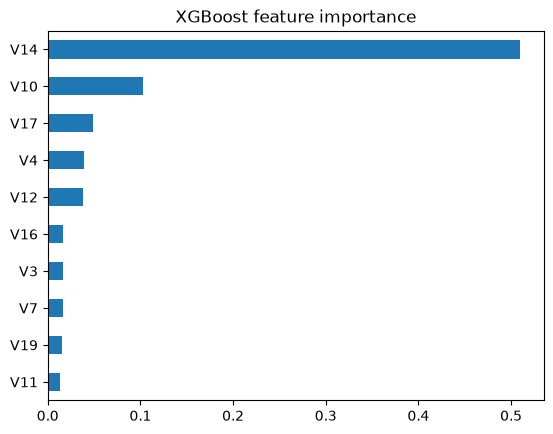

In [25]:
xgb = make_xgb(spw ** 0.5).fit(X_train, y_train)
imp = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=False)
imp.head(10).plot(kind="barh", title="XGBoost feature importance").invert_yaxis()
plt.show()

In [26]:
pd.DataFrame(results).round(3)

,model,imbalance,pr_auc,pr_auc_std,recall,precision,seconds,params
0,LogReg,none,0.756,0.039,0.628,0.868,1,{}
1,LogReg,class_weight,0.754,0.040,0.906,0.053,2,{}
2,LogReg,undersample,0.714,0.080,0.864,0.339,1,{}
3,LogReg,SMOTE,0.757,0.046,0.858,0.395,2,{}
4,RandomForest,none,0.843,0.024,0.764,0.935,39,"{'n_estimators': 100, 'max_depth': 12}"
5,RandomForest,class_weight,0.826,0.032,0.789,0.887,28,"{'n_estimators': 100, 'max_depth': 12}"
6,RandomForest,undersample,0.766,0.030,0.852,0.564,2,"{'n_estimators': 100, 'max_depth': 12}"
7,RandomForest,SMOTE,0.846,0.027,0.831,0.863,45,"{'n_estimators': 100, 'max_depth': 12}"
8,XGBoost,none,0.855,0.027,0.801,0.944,10,"{'n_estimators': 300, 'max_depth': 4, 'learnin..."
9,XGBoost,scale_pos_weight full,0.855,0.029,0.828,0.896,10,"{'n_estimators': 300, 'max_depth': 4, 'learnin..."


## XGBoost notes

- XGBoost none / full weight / sqrt weight: PR-AUC 0.855 / 0.855 / 0.855 — identical, confirming scale_pos_weight mainly shifts the probability threshold rather than improving ranking (same pattern seen with LogReg and RandomForest class_weight).
- Precision/recall at 0.5: none (0.944/0.801), full (0.896/0.828), sqrt (0.918/0.825). sqrt weight gives a good middle ground — nearly the recall of full weight with better precision.
- XGBoost is the best model so far (0.855 vs RF's 0.846 vs LogReg's 0.757), and by far the fastest to train (13s vs 45-51s for RandomForest).
- Top features: V14, V10, V17

## Tracking experiments with MLflow

In [27]:
import mlflow

mlflow.set_tracking_uri("sqlite:///../mlflow.db")   # creates mlflow.db in the project root
mlflow.set_experiment("fraud-detection-model-comparison")

def log_to_mlflow(row):
    with mlflow.start_run(run_name=f"{row['model']} | {row['imbalance']}"):
        mlflow.log_param("model", row["model"])
        mlflow.log_param("imbalance", row["imbalance"])
        mlflow.log_param("model_params", row["params"])
        mlflow.log_param("cv_folds", 5)
        mlflow.log_metric("cv_pr_auc", row["pr_auc"])
        mlflow.log_metric("cv_pr_auc_std", row["pr_auc_std"])
        mlflow.log_metric("cv_recall", row["recall"])
        mlflow.log_metric("cv_precision", row["precision"])
        mlflow.log_metric("train_seconds", row["seconds"])

saved = pd.read_csv(RESULTS_PATH).drop_duplicates(["model", "imbalance"], keep="last")
for _, r in saved.iterrows():
    log_to_mlflow(r)

print("Logged", len(saved), "runs")

Logged 11 runs


## MLflow notes

- All 11 experiments logged in MLflow (experiment "fraud-detection-model-comparison").
- Best run by CV PR-AUC: XGBoost | scale_pos_weight sqrt (0.855 ± 0.028).
- Parallel coordinates plot confirms XGBoost consistently outperforms RandomForest and LogReg regardless of the imbalance strategy used.

## Final comparaison table and chart

,label,pr_auc,pr_auc_std,recall,precision,seconds
0,XGBoost | scale_pos_weight sqrt,0.855,0.028,0.825,0.918,10
1,XGBoost | none,0.855,0.027,0.801,0.944,10
2,XGBoost | scale_pos_weight full,0.855,0.029,0.828,0.896,10
3,RandomForest | SMOTE,0.846,0.027,0.831,0.863,45
4,RandomForest | none,0.843,0.024,0.764,0.935,39
5,RandomForest | class_weight,0.826,0.032,0.789,0.887,28
6,RandomForest | undersample,0.766,0.030,0.852,0.564,2
7,LogReg | SMOTE,0.757,0.046,0.858,0.395,2
8,LogReg | none,0.756,0.039,0.628,0.868,1
9,LogReg | class_weight,0.754,0.040,0.906,0.053,2


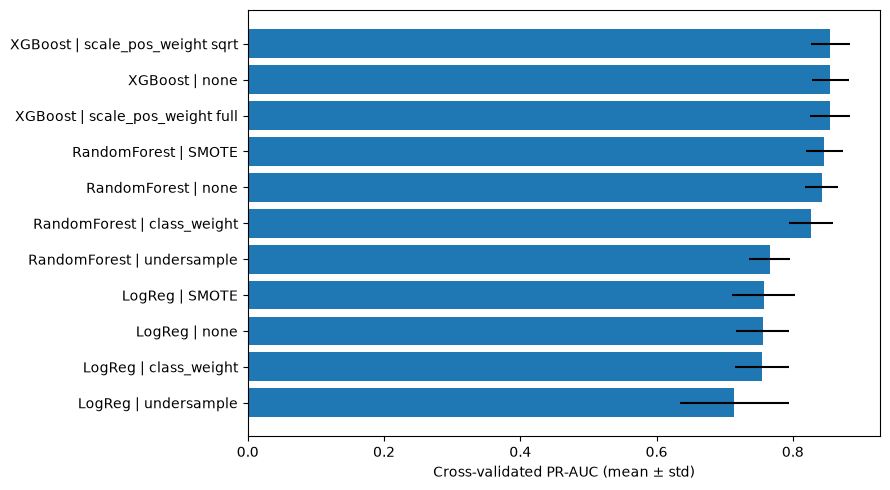

In [28]:
res = pd.read_csv(RESULTS_PATH).drop_duplicates(["model", "imbalance"], keep="last")
res = res.sort_values("pr_auc", ascending=False).reset_index(drop=True)
res["label"] = res["model"] + " | " + res["imbalance"]
display(res[["label", "pr_auc", "pr_auc_std", "recall", "precision", "seconds"]].round(3))

plt.figure(figsize=(9, 5))
plt.barh(res["label"], res["pr_auc"], xerr=res["pr_auc_std"])
plt.gca().invert_yaxis()
plt.xlabel("Cross-validated PR-AUC (mean ± std)")
plt.tight_layout()
plt.show()

## Validating the top 3 on the validation set

In [29]:
finalists = {
    "XGB | sqrt weight": make_xgb(spw ** 0.5),
    "RF | SMOTE": rf_pipeline(SMOTE(sampling_strategy=0.1, random_state=42)),
    "RF | none": rf_pipeline(),
}

rows, probas = [], {}
for name, model in finalists.items():
    model.fit(X_train, y_train)
    probas[name] = model.predict_proba(X_val)[:, 1]
    rows.append({"name": name, **evaluate(y_val, probas[name])})

pd.DataFrame(rows).round(3)

,name,pr_auc,precision,recall,f1,frauds_caught,false_alarms
0,XGB | sqrt weight,0.847,1.000,0.761,0.864,54,0
1,RF | SMOTE,0.842,0.947,0.761,0.844,54,3
2,RF | none,0.820,0.981,0.746,0.848,53,1


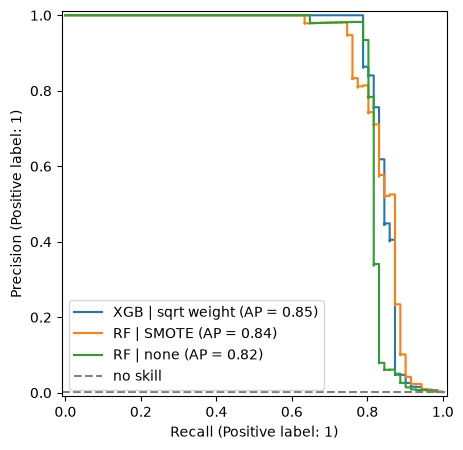

In [30]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, p in probas.items():
    PrecisionRecallDisplay.from_predictions(y_val, p, name=name, ax=ax)
ax.axhline(y_val.mean(), ls="--", c="gray", label="no skill")
ax.legend()
plt.show()

## Model Comparison: Conclusion

- **Winner: XGBoost (scale_pos_weight = sqrt(neg/pos))**
  CV PR-AUC: 0.855 ± 0.028 | Validation PR-AUC: 0.847
  Validation: 54/71 frauds caught, 0 false alarms, at the default 0.5 threshold.
- **Why:** Highest PR-AUC on both cross-validation and the held-out validation set, consistent ranking between the two. Also by far the fastest to train (13s vs 45-51s for RandomForest), which matters for hyperparameter tuning.
- **Imbalance strategy:** made little difference for XGBoost (all three weightings scored 0.855 on CV); scale_pos_weight mainly shifts the decision threshold rather than improving the model's ranking ability.
- **Caveat:** the validation set has only 71 frauds, so small differences between the top 3 models (0.820-0.847) should be interpreted cautiously.
- **Next:** tune XGBoost with Optuna, choose a threshold using cost-based analysis, and explain it with SHAP.